**Check GPU availability and Torch version**

In [ ]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


**Install dependencies (first-time run)**

In [ ]:
!pip install transformers datasets tiktoken wandb --upgrade
!pip install torch torchvision matplotlib --upgrade

**Clone Sophia repo (first-time run)**

In [ ]:
!git clone https://github.com/Liuhong99/Sophia.git

fatal: destination path 'Sophia' already exists and is not an empty directory.


**Import libraries**

In [ ]:
import sys
sys.path.append("/content/Sophia")
from sophia import SophiaG
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.07MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


Label: 5


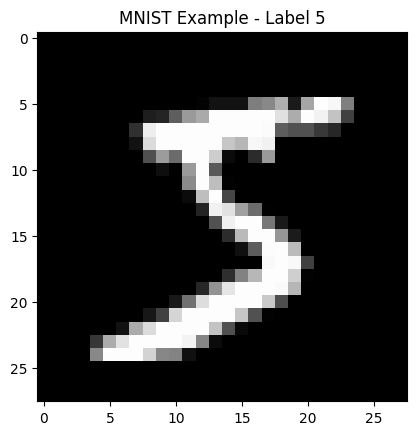

In [ ]:
transform = transforms.ToTensor()
trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)

img, label = trainset[0]

print("Label:", label)
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"MNIST Example - Label {label}")
plt.show()

**Set device and training parameters**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Adjustable parameters
BATCH_SIZE = 512   # Batch size for training
EPOCHS = 10        # Number of epochs to train
LR = 1e-3          # Learning rate

**Prepare MNIST dataset**

In [ ]:
transform = transforms.ToTensor()
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)

**Define simple MLP model**

In [ ]:
# Simple MLP
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.fc(x)

**Training function**

In [ ]:
def train_model(optimizer_name):
    model = Net().to(device)

    if optimizer_name == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=1e-3)
    else:
        optimizer = SophiaG(model.parameters(), lr=1e-3,
                            betas=(0.965, 0.99), rho=0.01,
                            weight_decay=0.01)

    criterion = nn.CrossEntropyLoss()
    losses = []

    for epoch in range(2):  # only 2 epochs
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()

            if optimizer_name == "adamw":
                optimizer.step()
            else:
                optimizer.step(bs=256)

            optimizer.zero_grad()
            losses.append(loss.item())

    return losses

**Train both AdamW and SophiaG**

In [ ]:
adam_losses = train_model("adamw")
sophia_losses = train_model("sophia")

**Plot loss comparison**

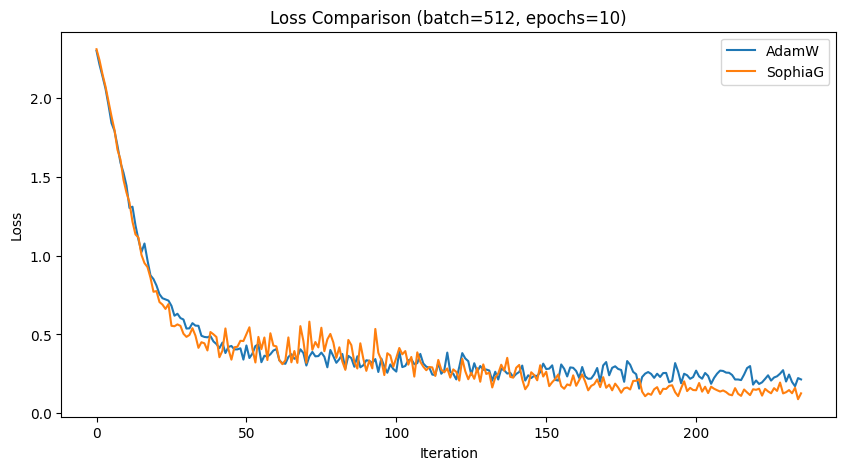

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(adam_losses, label="AdamW")
plt.plot(sophia_losses, label="SophiaG")
plt.legend()
plt.title(f"Loss Comparison (batch={BATCH_SIZE}, epochs={EPOCHS})")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

Experiment 2

In [ ]:
import sys
sys.path.append("/content/Sophia")

from sophia import SophiaG

# basic imports & device
import random, numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.10.0+cu128
CUDA available: True


In [ ]:
# Hyperparams & MNIST data
BATCH_SIZE = 512
LR = 1e-3

MAX_STEPS  = 2000
LOG_EVERY  = 100
EVAL_EVERY = 200
SEED       = 42

transform = transforms.ToTensor()
trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
testset  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
# Simple MLP model
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.fc(x)


# Utils: seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


@torch.no_grad()
def eval_model(model, loader):
    """Evaluate on the given loader (here, testloader) and return (avg_loss, acc)"""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    model.train()
    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


@torch.no_grad()
def compute_clip_prop(optimizer, rho=None, bs=1, eps=1e-15, gamma=1.0):
    """
    Calculate the proportion of "clipping coordinates" in the current step using `clip_prop`.
    Official SophiaG update:

    `ratio_raw = |m| / (rho * bs * h + eps)`
    `ratio = ratio_raw.clamp(max=1) # γ = 1`

    Therefore:

    Clipping condition = ratio_raw > 1 (Here, the gamma parameter is used to reserve expansion space)

    """
    total_elems = 0
    clip_elems = 0

    if rho is None:
        rho = optimizer.param_groups[0].get("rho", None)
    if rho is None:
        return None

    for p, st in optimizer.state.items():
        if not isinstance(st, dict):
            continue
        if ("exp_avg" not in st) or ("hessian" not in st):
            continue

        m = st["exp_avg"]
        h = st["hessian"]

        if (m is None) or (h is None):
            continue
        if (not torch.is_tensor(m)) or (not torch.is_tensor(h)):
            continue
        if m.numel() == 0:
            continue

        denom = rho * bs * h + eps
        ratio_raw = m.abs() / denom

        total_elems += ratio_raw.numel()
        clip_elems += (ratio_raw > gamma).sum().item()

    if total_elems == 0:
        return None

    clip_prop = clip_elems / total_elems
    return clip_prop


def train_sophia_with_rho(
    rho,
    seed=42,
    max_steps=MAX_STEPS,
    log_every=LOG_EVERY,
    eval_every=EVAL_EVERY,
    gamma=1.0,
):
    set_seed(seed)
    model = Net().to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = SophiaG(
        model.parameters(),
        lr=LR,
        betas=(0.965, 0.99),
        rho=rho,
        weight_decay=0.01,
    )

    print("optimizer group rho =", optimizer.param_groups[0].get("rho", None))

    steps = 0
    val_steps = []
    val_losses = []
    clip_props = []

    train_iter = iter(trainloader)

    while steps < max_steps:
        try:
            x, y = next(train_iter)
        except StopIteration:
            train_iter = iter(trainloader)
            x, y = next(train_iter)

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.update_hessian()

        optimizer.step(bs=BATCH_SIZE)
        steps += 1

        if steps % log_every == 0:
            clip_prop = compute_clip_prop(optimizer, rho=rho, bs=BATCH_SIZE, gamma=gamma)
            clip_props.append(clip_prop)

        if steps % eval_every == 0:
            val_loss, _ = eval_model(model, testloader)
            val_steps.append(steps)
            val_losses.append(val_loss)
            print(f"[rho={rho}] step {steps} | val_loss={val_loss:.4f}")

    return {
        "val_steps": val_steps,
        "val_losses": val_losses,
        "clip_props": clip_props,
    }


In [ ]:
# rho sweep
RHO_LIST = [1e-4, 1e-2, 1e-0]
SEED = SEED

results = {}  # rho -> dict

for rho in RHO_LIST:
    print("=" * 40)
    print(f"Run with rho={rho}")
    res = train_sophia_with_rho(
        rho=rho,
        seed=SEED,
        max_steps=MAX_STEPS,
        log_every=LOG_EVERY,
        eval_every=EVAL_EVERY,
    )
    results[rho] = res

# best_rho（Min val_loss）
best_rho = min(
    RHO_LIST,
    key=lambda r: results[r]["val_losses"][-1] if results[r]["val_losses"] else float("inf"),
)
print("\nBest rho by final val_loss:", best_rho)

RHO_NOCLIP = 1e6
print("\nRun approximate No-Clip with very large rho =", RHO_NOCLIP)
res_noclip = train_sophia_with_rho(
    rho=RHO_NOCLIP,
    seed=SEED,
    max_steps=MAX_STEPS,
    log_every=LOG_EVERY,
    eval_every=EVAL_EVERY,
)

final_val_nc = res_noclip["val_losses"][-1] if res_noclip["val_losses"] else float("inf")
cp_nc = [c for c in res_noclip["clip_props"] if c is not None]
mean_clip_nc = np.mean(cp_nc) if cp_nc else np.nan
print(f"No-Clip approx (rho={RHO_NOCLIP}): final_val_loss={final_val_nc:.4f}, mean_clip_prop={mean_clip_nc:.4f}")


Run with rho=0.0001
optimizer group rho = 0.0001
[rho=0.0001] step 200 | val_loss=0.1455
[rho=0.0001] step 400 | val_loss=0.0971
[rho=0.0001] step 600 | val_loss=0.0880
[rho=0.0001] step 800 | val_loss=0.1062
[rho=0.0001] step 1000 | val_loss=0.1177
[rho=0.0001] step 1200 | val_loss=0.1323
[rho=0.0001] step 1400 | val_loss=0.1301
[rho=0.0001] step 1600 | val_loss=0.1280
[rho=0.0001] step 1800 | val_loss=0.1650
[rho=0.0001] step 2000 | val_loss=0.1779
Run with rho=0.01
optimizer group rho = 0.01
[rho=0.01] step 200 | val_loss=0.1385
[rho=0.01] step 400 | val_loss=0.0923
[rho=0.01] step 600 | val_loss=0.0855
[rho=0.01] step 800 | val_loss=0.1070
[rho=0.01] step 1000 | val_loss=0.0989
[rho=0.01] step 1200 | val_loss=0.1204
[rho=0.01] step 1400 | val_loss=0.1111
[rho=0.01] step 1600 | val_loss=0.1400
[rho=0.01] step 1800 | val_loss=0.1428
[rho=0.01] step 2000 | val_loss=0.1624
Run with rho=1.0
optimizer group rho = 1.0
[rho=1.0] step 200 | val_loss=0.1800
[rho=1.0] step 400 | val_loss=0.11

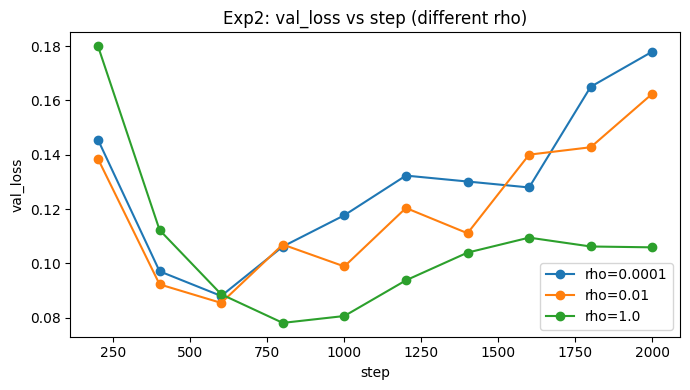

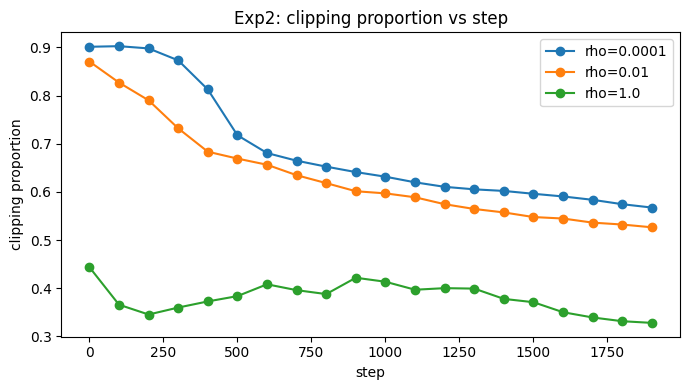

rho	final_val_loss	mean_clip_prop
----------------------------------------
0.0001	0.1779		0.6862
0.01	0.1624		0.6326
1.0	0.1059		0.3797


In [ ]:
#  Figure 1: val_loss curves (multiple rho lines)
plt.figure(figsize=(7, 4))
for rho in RHO_LIST:
    st = results[rho]
    plt.plot(st["val_steps"], st["val_losses"], marker="o", label=f"rho={rho}")
plt.xlabel("step")
plt.ylabel("val_loss")
plt.title("Exp2: val_loss vs step (different rho)")
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2: clip_prop curves (multiple rho lines)
plt.figure(figsize=(7, 4))
for rho in RHO_LIST:
    cp = results[rho]["clip_props"]
    steps = np.arange(len(cp)) * LOG_EVERY
    plt.plot(steps, cp, marker="o", label=f"rho={rho}")
plt.xlabel("step")
plt.ylabel("clipping proportion")
plt.title("Exp2: clipping proportion vs step")
plt.legend()
plt.tight_layout()
plt.show()

# Summary table: Final val_loss + average clip_prop for each rho
print("rho\tfinal_val_loss\tmean_clip_prop")
print("-" * 40)
for rho in RHO_LIST:
    st = results[rho]
    final_val = st["val_losses"][-1] if st["val_losses"] else np.nan
    cp = [c for c in st["clip_props"] if c is not None]
    mean_clip = np.mean(cp) if cp else np.nan
    print(f"{rho}\t{final_val:.4f}\t\t{mean_clip:.4f}")
